# Fluvial flooding

In [328]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import glob
import os

In [329]:
pd.set_option('display.max_rows', 500)

In [330]:
from vista_criticality_utils import *

In [2]:
# Reload modules
import importlib
import vista_criticality_utils
importlib.reload(vista_criticality_utils)
from vista_criticality_utils import *

# 1. Load assets to a new graph

In [3]:
asset_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/02-fluvial-flooding.csv'
dependency_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/02-dependency-mapping.csv'

In [4]:
incident_data = pd.read_csv(asset_file)
dependency_data = pd.read_csv(dependency_file)

In [5]:
incident_data.head(100)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN
...,...,...,...,...,...,...,...
95,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03
96,WS03,WaterSupply,WaterDistributionComplex,50.618279,-1.189187,3,WS04
97,WS04,WaterSupply,WaterExtractionComplex,50.657489,-1.307015,3,NaN
98,WS05,WaterSupply,WaterReservoir,50.680195,-1.198740,3,NaN


In [6]:
incident_data.shape

(133, 7)

In [7]:
dependency_data.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS07,BSC04,PGS07-->BSC04,2
1,PGS07,TRR03,PGS07-->TRR03,2
2,PGS07,NH02,PGS07-->NH02,2
3,PGS07,TEL03,PGS07-->TEL03,2
4,PGS07,VH05,PGS07-->VH05,2
5,PGS07,NH04,PGS07-->NH04,2
6,PGS07,FS07,PGS07-->FS07,2
7,PGS04,FS03,PGS04-->FS03,2
8,PGS04,BSC02,PGS04-->BSC02,2
9,PGS04,SCH02,PGS04-->SCH02,2


In [8]:
dependency_data.shape

(126, 4)

Show Dependency Mapper Demo on Browser....

In [9]:
G = load_assets_to_graph(assets_filepath=asset_file)

Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/02-fluvial-flooding.csv
Added 133 nodes to the graph.


In [10]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working'}

# 2. Add Dependencies to Graph

In [11]:
G = add_dependencies_to_graph(graph=G, dependencies_filepath=dependency_file)


Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/02-dependency-mapping.csv
Added edges. The graph now has 124 edges.


In [12]:
## Add dependency score as node attributes
G = compute_dependency_score(G=G)

In [13]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 2}

In [14]:
incident_data = graph_to_dataframe(G)

In [15]:
incident_data.head(20) # Assets now with dependenc scores

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,working,0
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,working,0


# 3. Exposure Score

In [16]:
flood_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/flood_files'
heat_stress_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/heat_stress_files'
landslide_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/landslide_files'

In [17]:
# Construct the search pattern to find all .geojson files in the specified folder
flood_geojson_search_pattern = os.path.join(flood_layers, '*.geojson')
flood_geojson_file_paths = glob.glob(flood_geojson_search_pattern)

heat_geojson_search_pattern = os.path.join(heat_stress_layers, '*.geojson')
heat_geojson_file_paths = glob.glob(heat_geojson_search_pattern)

landslide_geojson_search_pattern = os.path.join(landslide_layers, '*.geojson')
landslide_geojson_file_paths = glob.glob(landslide_geojson_search_pattern)

In [18]:
incident_data = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths)
incident_data.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0,2
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0,2
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0,0
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0,2
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0,2
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,working,0,0
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0,1
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0,2
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0,0
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,working,0,0


In [19]:
## Export data with exposure scores
# incident_data.to_csv('exposure_score_with_flood_layer.csv', index=False)

In [20]:
incident_data_with_heat_stress_layer = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths)

In [21]:
incident_data_with_heat_stress_layer.head(20) # Exposure

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0,2
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0,3
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0,0
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0,2
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0,2
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,working,0,0
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0,1
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0,2
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0,0
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,working,0,0


In [22]:
# incident_data_with_heat_stress_layer.to_csv('exposure_score_with_flood_heat_layer.csv', index=False)

In [23]:
incident_data_with_heat_stress_landslide_layer= compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths, landslide_files=landslide_geojson_file_paths)

In [24]:
incident_data_with_heat_stress_landslide_layer.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0,2
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0,3
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0,0
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0,2
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0,2
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,working,0,0
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0,1
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0,2
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0,0
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,working,0,0


In [25]:
#incident_data_with_heat_stress_landslide_layer.to_csv('exposure_score_with_flood_heat_landslide_layer.csv',index=False)

In [26]:
incident_data = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths)
incident_data.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0,2
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0,2
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0,0
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0,2
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0,2
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,working,0,0
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0,1
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0,2
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0,0
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,working,0,0


# 4. Redundancy Score

In [27]:
incident_data = compute_redundancy_score(df=incident_data)

In [28]:
incident_data.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0,2,2
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0,2,2
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0,0,3
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0,2,3
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0,2,3
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,working,0,0,3
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0,1,3
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0,2,3
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0,0,3
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,working,0,0,3


### Add exposure and redundancy scores as graph node addtributes

In [29]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='exposure_score')

Added exposure_score to the graph.


In [30]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 2,
 'exposure_score': 1}

In [31]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='redundancy_score')

Added redundancy_score to the graph.


In [32]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 3}

# 5. Compute Asset Score

In [33]:
G = compute_asset_score(G=G)

Added asset_score to assets.


In [34]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 9}

# 6. Simulate failure

In [35]:
failed_nodes = simulate_failure(G=G, failed_node='PGS01')

Failing: PGS01
Propagated failure to: VH01 (via dependency 2.0)
Propagated failure to: BSC06 (via dependency 2.0)
Propagated failure to: SCH04 (via dependency 2.0)
Propagated failure to: TRR10 (via dependency 2.0)
Propagated failure to: TRR08 (via dependency 2.0)
Propagated failure to: FS05 (via dependency 2.0)
Propagated failure to: TRF04 (via dependency 2.0)
Propagated failure to: PH01 (via dependency 2.0)
Propagated failure to: FS06 (via dependency 2.0)
Propagated failure to: BSC10 (via dependency 2.0)
Propagated failure to: TEL07 (via dependency 2.0)
Propagated failure to: TRF03 (via dependency 2.0)
Propagated failure to: TRR09 (via dependency 2.0)
Propagated failure to: TRR05 (via dependency 2.0)
Propagated failure to: TRR04 (via dependency 2.0)


In [39]:
len(failed_nodes)

15

Initiating failure at node: PGS01
Propagated failure to: VH01 (dependency: 2.00 >= 1)
Propagated failure to: BSC06 (dependency: 2.00 >= 1)
Propagated failure to: SCH04 (dependency: 2.00 >= 1)
Propagated failure to: TRR10 (dependency: 2.00 >= 1)
Propagated failure to: TRR08 (dependency: 2.00 >= 1)
Propagated failure to: FS05 (dependency: 2.00 >= 1)
Propagated failure to: TRF04 (dependency: 2.00 >= 1)
Propagated failure to: PH01 (dependency: 2.00 >= 1)
Propagated failure to: FS06 (dependency: 2.00 >= 1)
Propagated failure to: BSC10 (dependency: 2.00 >= 1)
Propagated failure to: TEL07 (dependency: 2.00 >= 1)
Propagated failure to: TRF03 (dependency: 2.00 >= 1)
Propagated failure to: TRR09 (dependency: 2.00 >= 1)
Propagated failure to: TRR05 (dependency: 2.00 >= 1)
Propagated failure to: TRR04 (dependency: 2.00 >= 1)


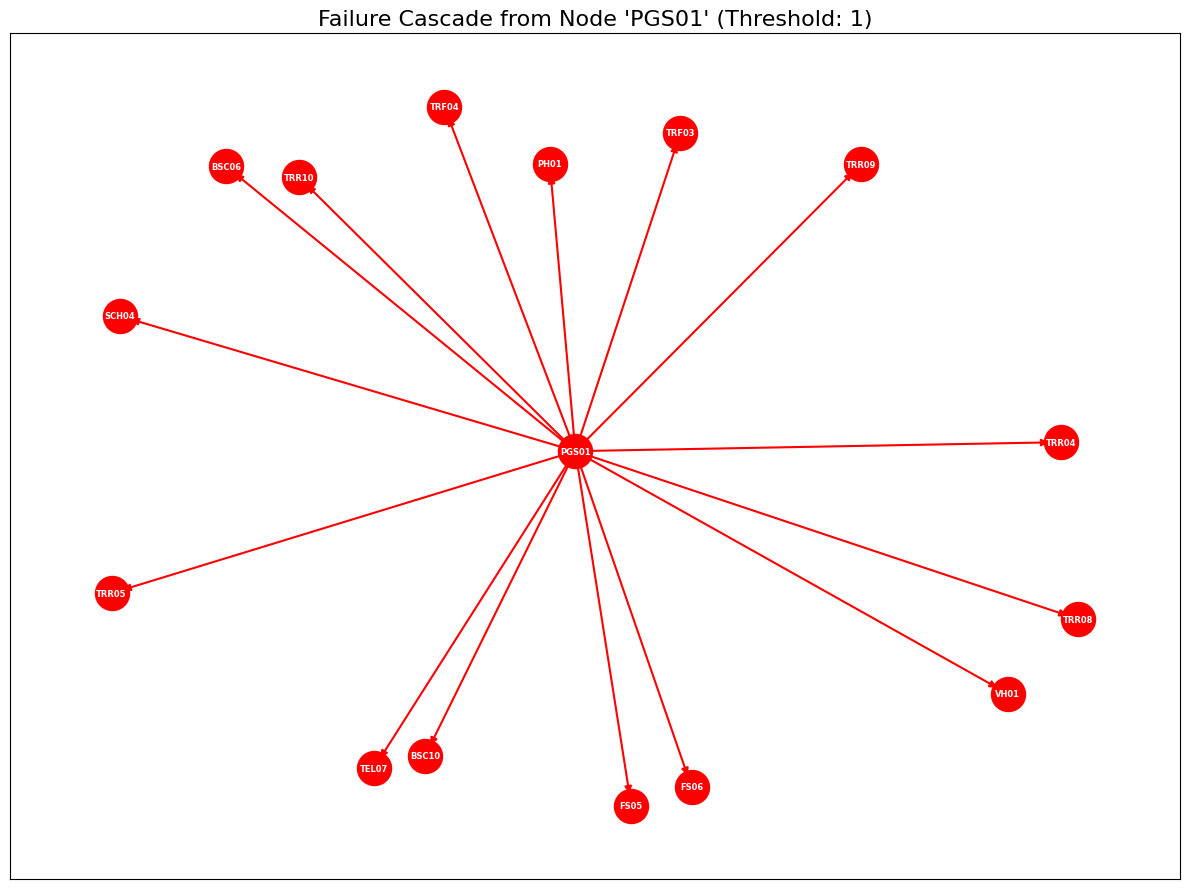

(['VH01',
  'BSC06',
  'SCH04',
  'TRR10',
  'TRR08',
  'FS05',
  'TRF04',
  'PH01',
  'FS06',
  'BSC10',
  'TEL07',
  'TRF03',
  'TRR09',
  'TRR05',
  'TRR04'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'PGS01' (Threshold: 1)"}>))

In [40]:
simulate_failure_with_plot(G, failed_node='PGS01', threshold=1)

In [41]:
check_node_and_edges(G, 'PGS01')


--- Analysis for Node: PGS01 ---

[Asset Attributes]
  - Asset_ID: PGS01
  - Asset_Type: PowerGen/Substation
  - Asset_Name: LowVoltageElectricitySubstationComplex
  - lat: 50.719325
  - long: -1.2020439
  - criticality_score: 3
  - backup_asset_id: nan
  - status: failed
  - dependency_score: 2
  - exposure_score: 1
  - redundancy_score: 3
  - asset_score: 9

[Outgoing Dependencies (This asset depends on...)]
  -> PGS01 impacts VH01 with dependency_score (weight): 2.0
  -> PGS01 impacts SCH04 with dependency_score (weight): 2.0
  -> PGS01 impacts BSC06 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR04 with dependency_score (weight): 2.0
  -> PGS01 impacts TEL07 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR05 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR10 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR09 with dependency_score (weight): 2.0
  -> PGS01 impacts TRF03 with dependency_score (weight): 2.0
  -> PGS01 impacts PH01 with dependen

# 7. Filter Graph by Criticality

In [42]:
G_criticality = filter_graph_by_criticality(G, threshold=3)


Filtered graph by criticality score >= 3.


In [43]:
G_criticality.number_of_nodes()

63

In [44]:
G_criticality.number_of_edges()

56

In [45]:
check_node_and_edges(G, 'TRF02')


--- Analysis for Node: TRF02 ---

[Asset Attributes]
  - Asset_ID: TRF02
  - Asset_Type: Transport
  - Asset_Name: FerryPort
  - lat: 50.763106
  - long: -1.2960338
  - criticality_score: 2
  - backup_asset_id: TRA01
  - status: working
  - dependency_score: 0
  - exposure_score: 0
  - redundancy_score: 2
  - asset_score: 4

[Outgoing Dependencies (This asset depends on...)]
  - None

[Incoming Dependencies (...depend on this asset)]
  <- PGS06 is parent to TRF02 with dependency_score (weight): 2.0
------------------------------


In [46]:
G_criticality.nodes()

NodeView(('NH04', 'TEL04', 'TEL08', 'TEL09', 'TEL01', 'TEL11', 'JN29', 'PGS01', 'JN12', 'PGS07', 'JN11', 'JN16', 'PGS08', 'JN13', 'JN15', 'WS03', 'JN18', 'JN14', 'JN21', 'NH01', 'TEL06', 'JN07', 'PGS05', 'JN22', 'TEL05', 'JN25', 'JN27', 'TEL10', 'JN02', 'JN03', 'JN05', 'JN19', 'JN04', 'JN31', 'JN33', 'JN06', 'JN34', 'HS01', 'WS05', 'JN10', 'JN09', 'PGS03', 'NH02', 'TEL02', 'TEL03', 'JN17', 'JN24', 'JN30', 'JN32', 'WS01', 'JN20', 'JN26', 'WS02', 'JN01', 'NH03', 'PGS04', 'JN23', 'WS04', 'JN28', 'JN08', 'TEL07', 'PGS02', 'PGS06'))

Initiating failure at node: PGS02
Propagated failure to: NH04 (dependency: 2.00 >= 1.0)
Propagated failure to: TEL01 (dependency: 2.00 >= 1.0)
Propagated failure to: NH01 (dependency: 2.00 >= 1.0)
Propagated failure to: NH03 (dependency: 2.00 >= 1.0)
Propagated failure to: HS01 (dependency: 2.00 >= 1.0)
Propagated failure to: NH02 (dependency: 2.00 >= 1.0)


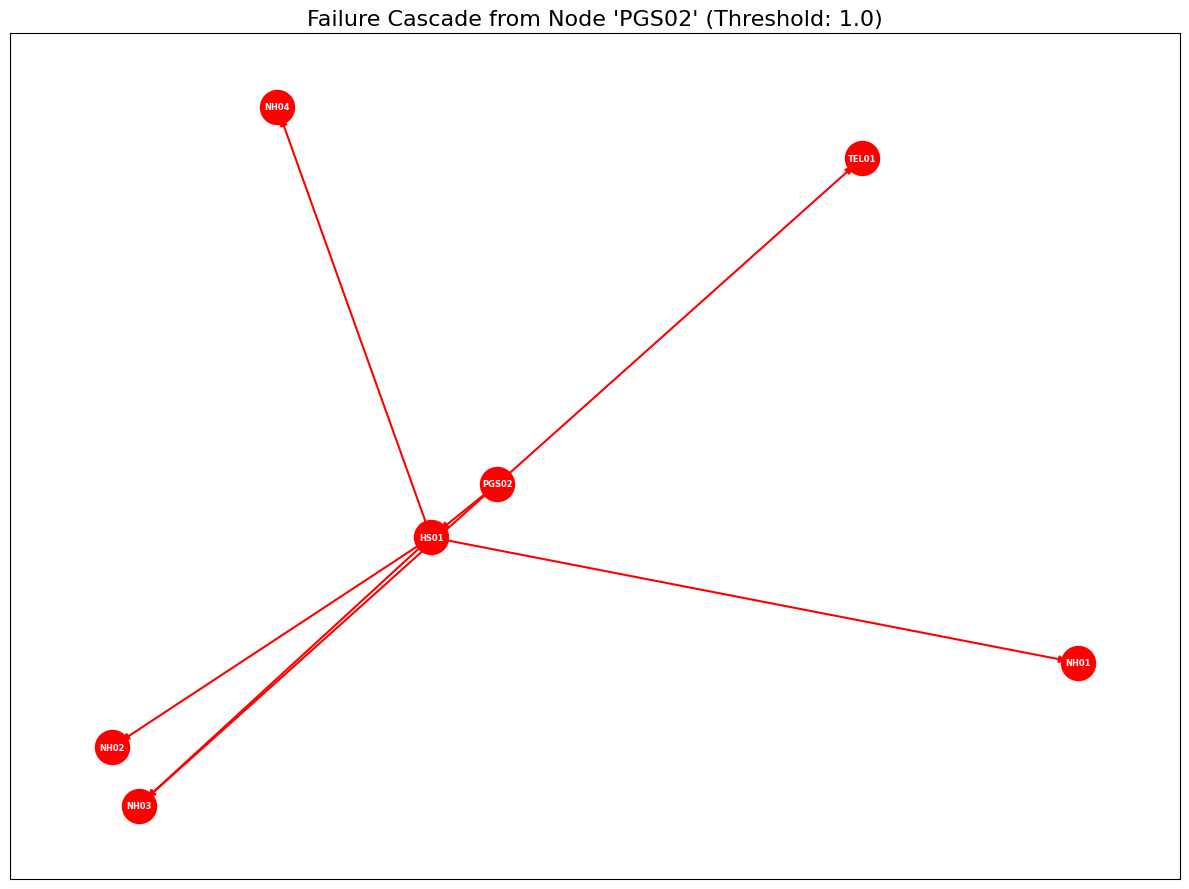

(['NH04', 'TEL01', 'NH01', 'NH03', 'HS01', 'NH02'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'PGS02' (Threshold: 1.0)"}>))

In [47]:
simulate_failure_with_plot(G_criticality, 'PGS02') #Only Criticality 3 assets shown

# 8. Add new assets and connections to network

In [48]:
new_asset_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/additional-new-assets.csv'
new_asset_mapping_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/additional-new-assets-mapping.csv'

In [49]:
new_assets = pd.read_csv(new_asset_file)
new_dependencies = pd.read_csv(new_asset_mapping_file)

In [50]:
new_assets.head()

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
0,PGS09,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.703494,-1.292065,3,NaN
1,LFS01,LiquidFuelStorage,LiquidFuelStorageComplex,50.748784,-1.288094,2,LFS02
2,LFS02,LiquidFuelStorage,LiquidFuelStorageComplex,50.745210,-1.287311,2,LFS03
3,LFS03,LiquidFuelStorage,LiquidFuelStorageComplex,50.755962,-1.292791,2,LFS01
4,TEL12,Telecomms,TelecommunicationsExchange,50.730509,-1.164576,3,NaN


In [51]:
new_dependencies.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS09,LFS02,PGS09-->LFS02,3
1,PGS09,LFS01,PGS09-->LFS01,3
2,PGS09,LFS03,PGS09-->LFS03,3
3,PGS09,TEL12,PGS09-->TEL12,3


In [52]:
G_assets = G.copy()

In [53]:
G_assets.number_of_nodes()


133

In [54]:
G_new_nodes =  add_new_assets_to_graph(G, new_assets)

Added 5 new assets and updated 0 existing assets.


In [55]:
G_new_nodes.number_of_nodes()


138

In [56]:
G_new_nodes = add_new_dependency_to_graph(G_new_nodes, new_dependencies)

Added 4 new dependencies.


In [ ]:
G_new_nodes.number_of_edges()

In [57]:
G_new_nodes = add_dependencies_to_graph(G_new_nodes, new_asset_mapping_file)


Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/additional-new-assets-mapping.csv
Added edges. The graph now has 128 edges.


In [58]:
check_node_and_edges(G_new_nodes, 'PGS09')


--- Analysis for Node: PGS09 ---

[Asset Attributes]
  - Asset_ID: PGS09
  - Asset_Type: PowerGen/Substation
  - Asset_Name: LowVoltageElectricitySubstationComplex
  - lat: 50.703494
  - long: -1.2920646
  - criticality_score: 3
  - backup_asset_id: nan
  - dependency_score: 3

[Outgoing Dependencies (This asset depends on...)]
  -> PGS09 impacts LFS02 with dependency_score (weight): 3.0
  -> PGS09 impacts LFS01 with dependency_score (weight): 3.0
  -> PGS09 impacts LFS03 with dependency_score (weight): 3.0
  -> PGS09 impacts TEL12 with dependency_score (weight): 3.0

[Incoming Dependencies (...depend on this asset)]
  - None
------------------------------


Initiating failure at node: PGS09
Propagated failure to: LFS02 (dependency: 3.00 >= 1.0)
Propagated failure to: TEL12 (dependency: 3.00 >= 1.0)
Propagated failure to: LFS03 (dependency: 3.00 >= 1.0)
Propagated failure to: LFS01 (dependency: 3.00 >= 1.0)


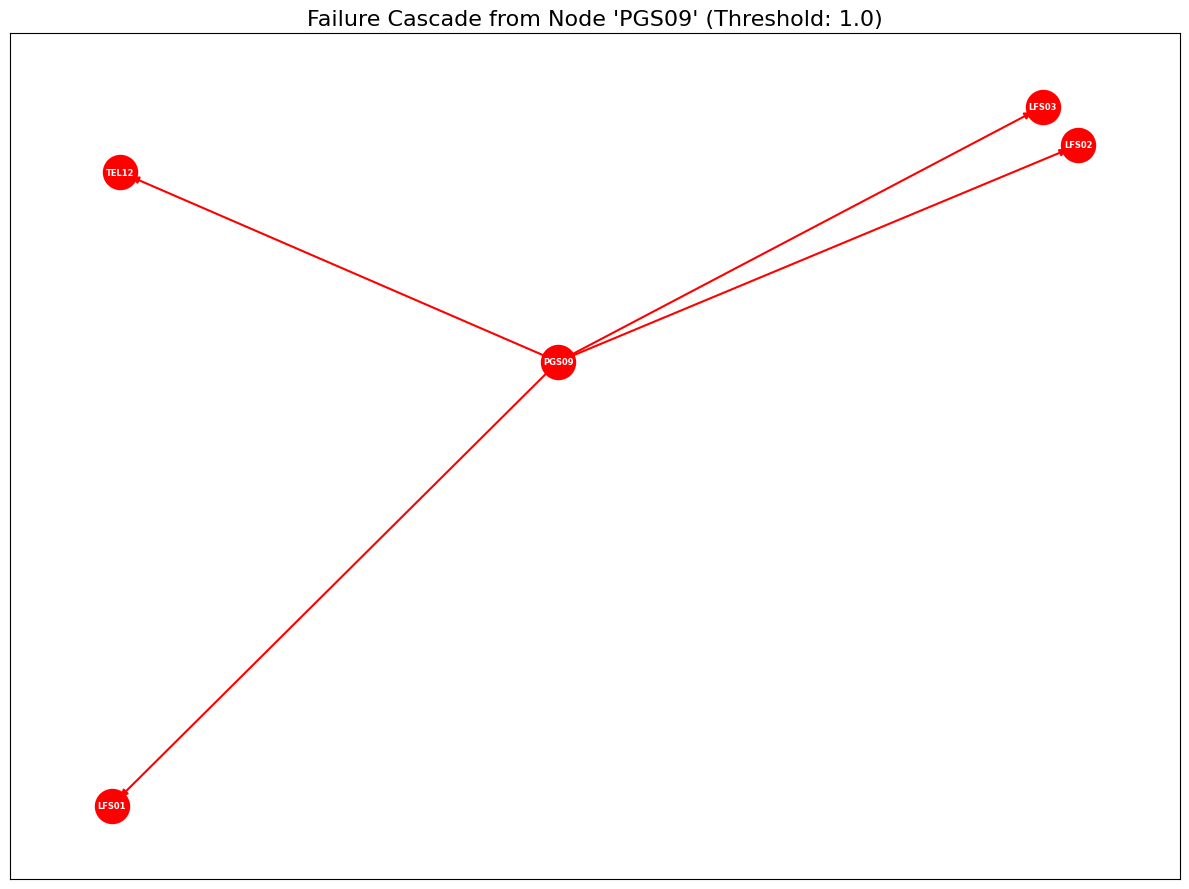

(['LFS02', 'TEL12', 'LFS03', 'LFS01'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'PGS09' (Threshold: 1.0)"}>))

In [59]:
simulate_failure_with_plot(G_new_nodes, 'PGS09')

In [60]:
incident_data_with_new_nodes = graph_to_dataframe(G_new_nodes)

In [61]:
incident_data_with_new_nodes.shape

(138, 12)

In [62]:
incident_data_with_new_nodes.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score,asset_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0.0,2.0,2.0,5.0
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0.0,2.0,2.0,5.0
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0.0,0.0,3.0,4.0
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0.0,2.0,3.0,6.0
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0.0,2.0,3.0,6.0
5,BSC06,Business/Commercial,RetailKiosk,50.718441,-1.158219,1,NaN,failed,0.0,0.0,3.0,4.0
6,BSC07,Business/Commercial,RetailKiosk,50.689932,-1.088592,1,NaN,working,0.0,1.0,3.0,5.0
7,BSC08,Business/Commercial,RetailKiosk,50.699454,-1.295762,1,NaN,working,0.0,2.0,3.0,6.0
8,BSC09,Business/Commercial,RetailKiosk,50.758017,-1.287798,1,NaN,working,0.0,0.0,3.0,4.0
9,BSC10,Business/Commercial,RetailKiosk,50.726535,-1.132907,1,NaN,failed,0.0,0.0,3.0,4.0


In [63]:
G_new_nodes.nodes['PGS09']


{'Asset_ID': 'PGS09',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.703494,
 'long': -1.2920646,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'dependency_score': 3,
 'status': 'failed'}

In [65]:
incident_data_with_new_nodes = compute_exposure_score(assets_df=incident_data_with_new_nodes, flood_files=flood_geojson_file_paths)
incident_data_with_new_nodes = compute_redundancy_score(df=incident_data_with_new_nodes)

In [ ]:
# incident_data_with_new_nodes.head(110)

In [66]:
G_new_nodes = add_attribute_from_df(G=G_new_nodes, df=incident_data_with_new_nodes, column_name='exposure_score')
G_new_nodes = add_attribute_from_df(G=G, df=incident_data_with_new_nodes, column_name='redundancy_score')

Added exposure_score to the graph.
Added redundancy_score to the graph.


In [67]:
G_new_nodes = compute_asset_score(G=G_new_nodes)

Added asset_score to assets.


In [68]:
G_new_nodes.nodes['PGS09']

{'Asset_ID': 'PGS09',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.703494,
 'long': -1.2920646,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'dependency_score': 3,
 'status': 'failed',
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 10}

In [69]:
new_assets_all_scores = graph_to_dataframe(G_new_nodes)

In [70]:
new_assets_all_scores


,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score,asset_score
0,BSC01,Business/Commercial,IndustrialSpace,50.701337,-1.298019,1,BSC02,working,0.0,2,2,5
1,BSC02,Business/Commercial,IndustrialSpace,50.662767,-1.150154,1,BSC03,working,0.0,2,2,5
2,BSC03,Business/Commercial,IndustrialSpace,50.757944,-1.290132,1,NaN,working,0.0,0,3,4
3,BSC04,Business/Commercial,IndustrialSpace,50.637089,-1.179144,1,NaN,working,0.0,2,3,6
4,BSC05,Business/Commercial,IndustrialSpace,50.591618,-1.255649,1,NaN,working,0.0,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...
133,PGS09,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.703494,-1.292065,3,NaN,failed,3.0,1,3,10
134,LFS01,LiquidFuelStorage,LiquidFuelStorageComplex,50.748784,-1.288094,2,LFS02,failed,NaN,0,0,2
135,LFS02,LiquidFuelStorage,LiquidFuelStorageComplex,50.745210,-1.287311,2,LFS03,failed,NaN,0,0,2
136,LFS03,LiquidFuelStorage,LiquidFuelStorageComplex,50.755962,-1.292791,2,LFS01,failed,NaN,0,0,2


In [71]:
G_new_nodes.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'failed',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 9}

In [ ]:
G_new_nodes.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'failed',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 9}

In [72]:
G_new_nodes.nodes['TRF02']

{'Asset_ID': 'TRF02',
 'Asset_Type': 'Transport',
 'Asset_Name': 'FerryPort',
 'lat': 50.763106,
 'long': -1.2960338,
 'criticality_score': 2,
 'backup_asset_id': 'TRA01',
 'status': 'working',
 'dependency_score': 0,
 'exposure_score': 0,
 'redundancy_score': 2,
 'asset_score': 4}